- https://github.com/RuthAngus/starspot

- https://www.aanda.org/articles/aa/abs/2013/12/aa21970-13/aa21970-13.html

# Setup

In [2]:
import sys
sys.path.append("..")


import lightkurve as lk
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

#from matplotlib_inline import backend_inline
#backend_inline.set_matplotlib_formats("svg")

import matplotlib.pyplot as plt
plt.rcParams.update({
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "font.family": "Lato",
    "ytick.direction": "in",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
    })

# Plotting the Light Curve of a Rotating Star

In [3]:
lc = lk.search_lightcurve("HD 223226").download().normalize(unit='ppm')

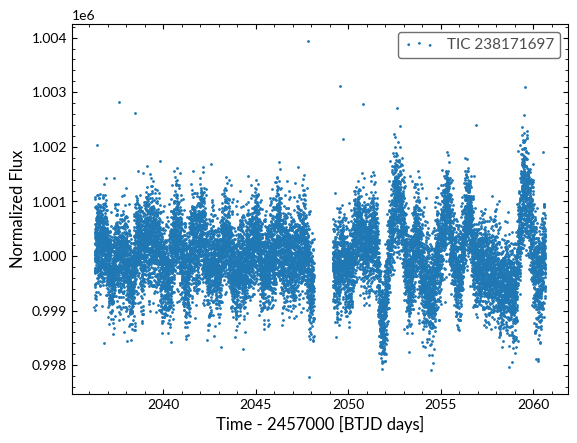

In [4]:
_, ax = plt.subplots()
lc.scatter(ax = ax);

# Plotting the Periodogram of a Rotating Star

1.3377336457506215


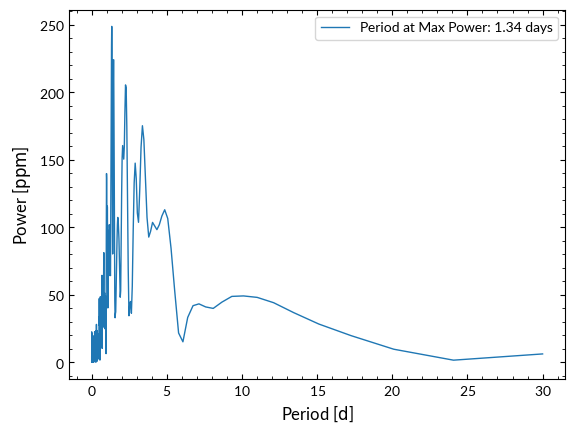

In [5]:
pg = lc.to_periodogram(maximum_period=30)
period = pg.period_at_max_power.value
print(period)

_, ax = plt.subplots()
pg.plot(view='period', ax = ax, lw=1)
ax.legend([f'Period at Max Power: {period:.2f} days']);

In [6]:
pg.show_properties()

lightkurve.Periodogram properties:
      Attribute         Description   Units
---------------------- -------------- -----
                nterms              1      
              targetid      238171697      
          default_view         period      
                 label  TIC 238171697      
             ls_method           fast      
frequency_at_max_power         0.7475 1 / d
             max_power       248.7422   ppm
               nyquist       359.9927 1 / d
   period_at_max_power         1.3377     d
             frequency array (43849,) 1 / d
                period array (43849,)     d
                 power array (43849,)   ppm
                  meta <class 'dict'>      


# Astropy LombScargle periodogram

In [7]:
import astropy.timeseries as apt

max_period = 100.
min_period = .5

freq = np.linspace(1./max_period, 1./min_period, 100000)
ps = 1./freq

power = apt.LombScargle(lc.time.value, lc.flux.value).power(freq)
peaks = np.array([i for i in range(1, len(ps)-1) if power[i-1] < power[i] and power[i+1] < power[i]])

if len(peaks) == 0:
    ls_period = 0
else:
    ls_period = ps[power == max(power[peaks])][0]
ls_period

1.3376121298021089

# Starspot

In [8]:
from utils.starspot import sigma_clipping as sc

flux_np = np.array(lc.flux.value)
flux_err_np = np.array(lc.flux_err.value)
time_np = np.array(lc.time.value)

# Calculate the median so that we can median-normalize.
med = np.median(flux_np)

# Do an initial sigma clip to remove big outliers.
m = sc.sigma_clip(flux_np/med - 1, nsigma=4)
x, y, yerr = time_np[m], flux_np[m]/med - 1, flux_err_np[m]/med

# Then a sigma clip using a Sav-Gol filter for smoothing
mask, smooth = sc.filter_sigma_clip(x, y, window_length=199)
time, flux, flux_err = x[mask], y[mask], yerr[mask]

In [9]:
from utils.starspot import starspot as ss
rotate = ss.RotationModel(time, flux, flux_err)

In [10]:
ls_period = rotate.ls_rotation()
ls_period

1.3374049697395725

In [11]:
import exoplanet as xo

# Calculate a LS period with a high-pass filter at 15 days using exoplanet.
results = xo.estimators.lomb_scargle_estimator(time, flux, max_peaks=1, min_period=.5, max_period=30, samples_per_peak=50, filter_period=15)

freq, power = results["periodogram"]
peak = results["peaks"][0]
ls_period = peak["period"]
ls_period

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


1.3373893538865287

In [12]:
acf_period = rotate.acf_rotation(interval="TESS")
acf_period

0.00555556

Phase Dispersion Minimization algorithm [Stellingwerf (1978)](https://ui.adsabs.harvard.edu/abs/1978ApJ...224..953S/abstract).

In [14]:
period_grid = np.linspace(.1, 2, 100)

# Set the number of bins to 10
pdm_period, period_err = rotate.pdm_rotation(period_grid, pdm_nbins=5)
pdm_period, period_err

100%|██████████| 100/100 [00:00<00:00, 317.37it/s]


(1.3474747474747475, 0.09206595653180492)

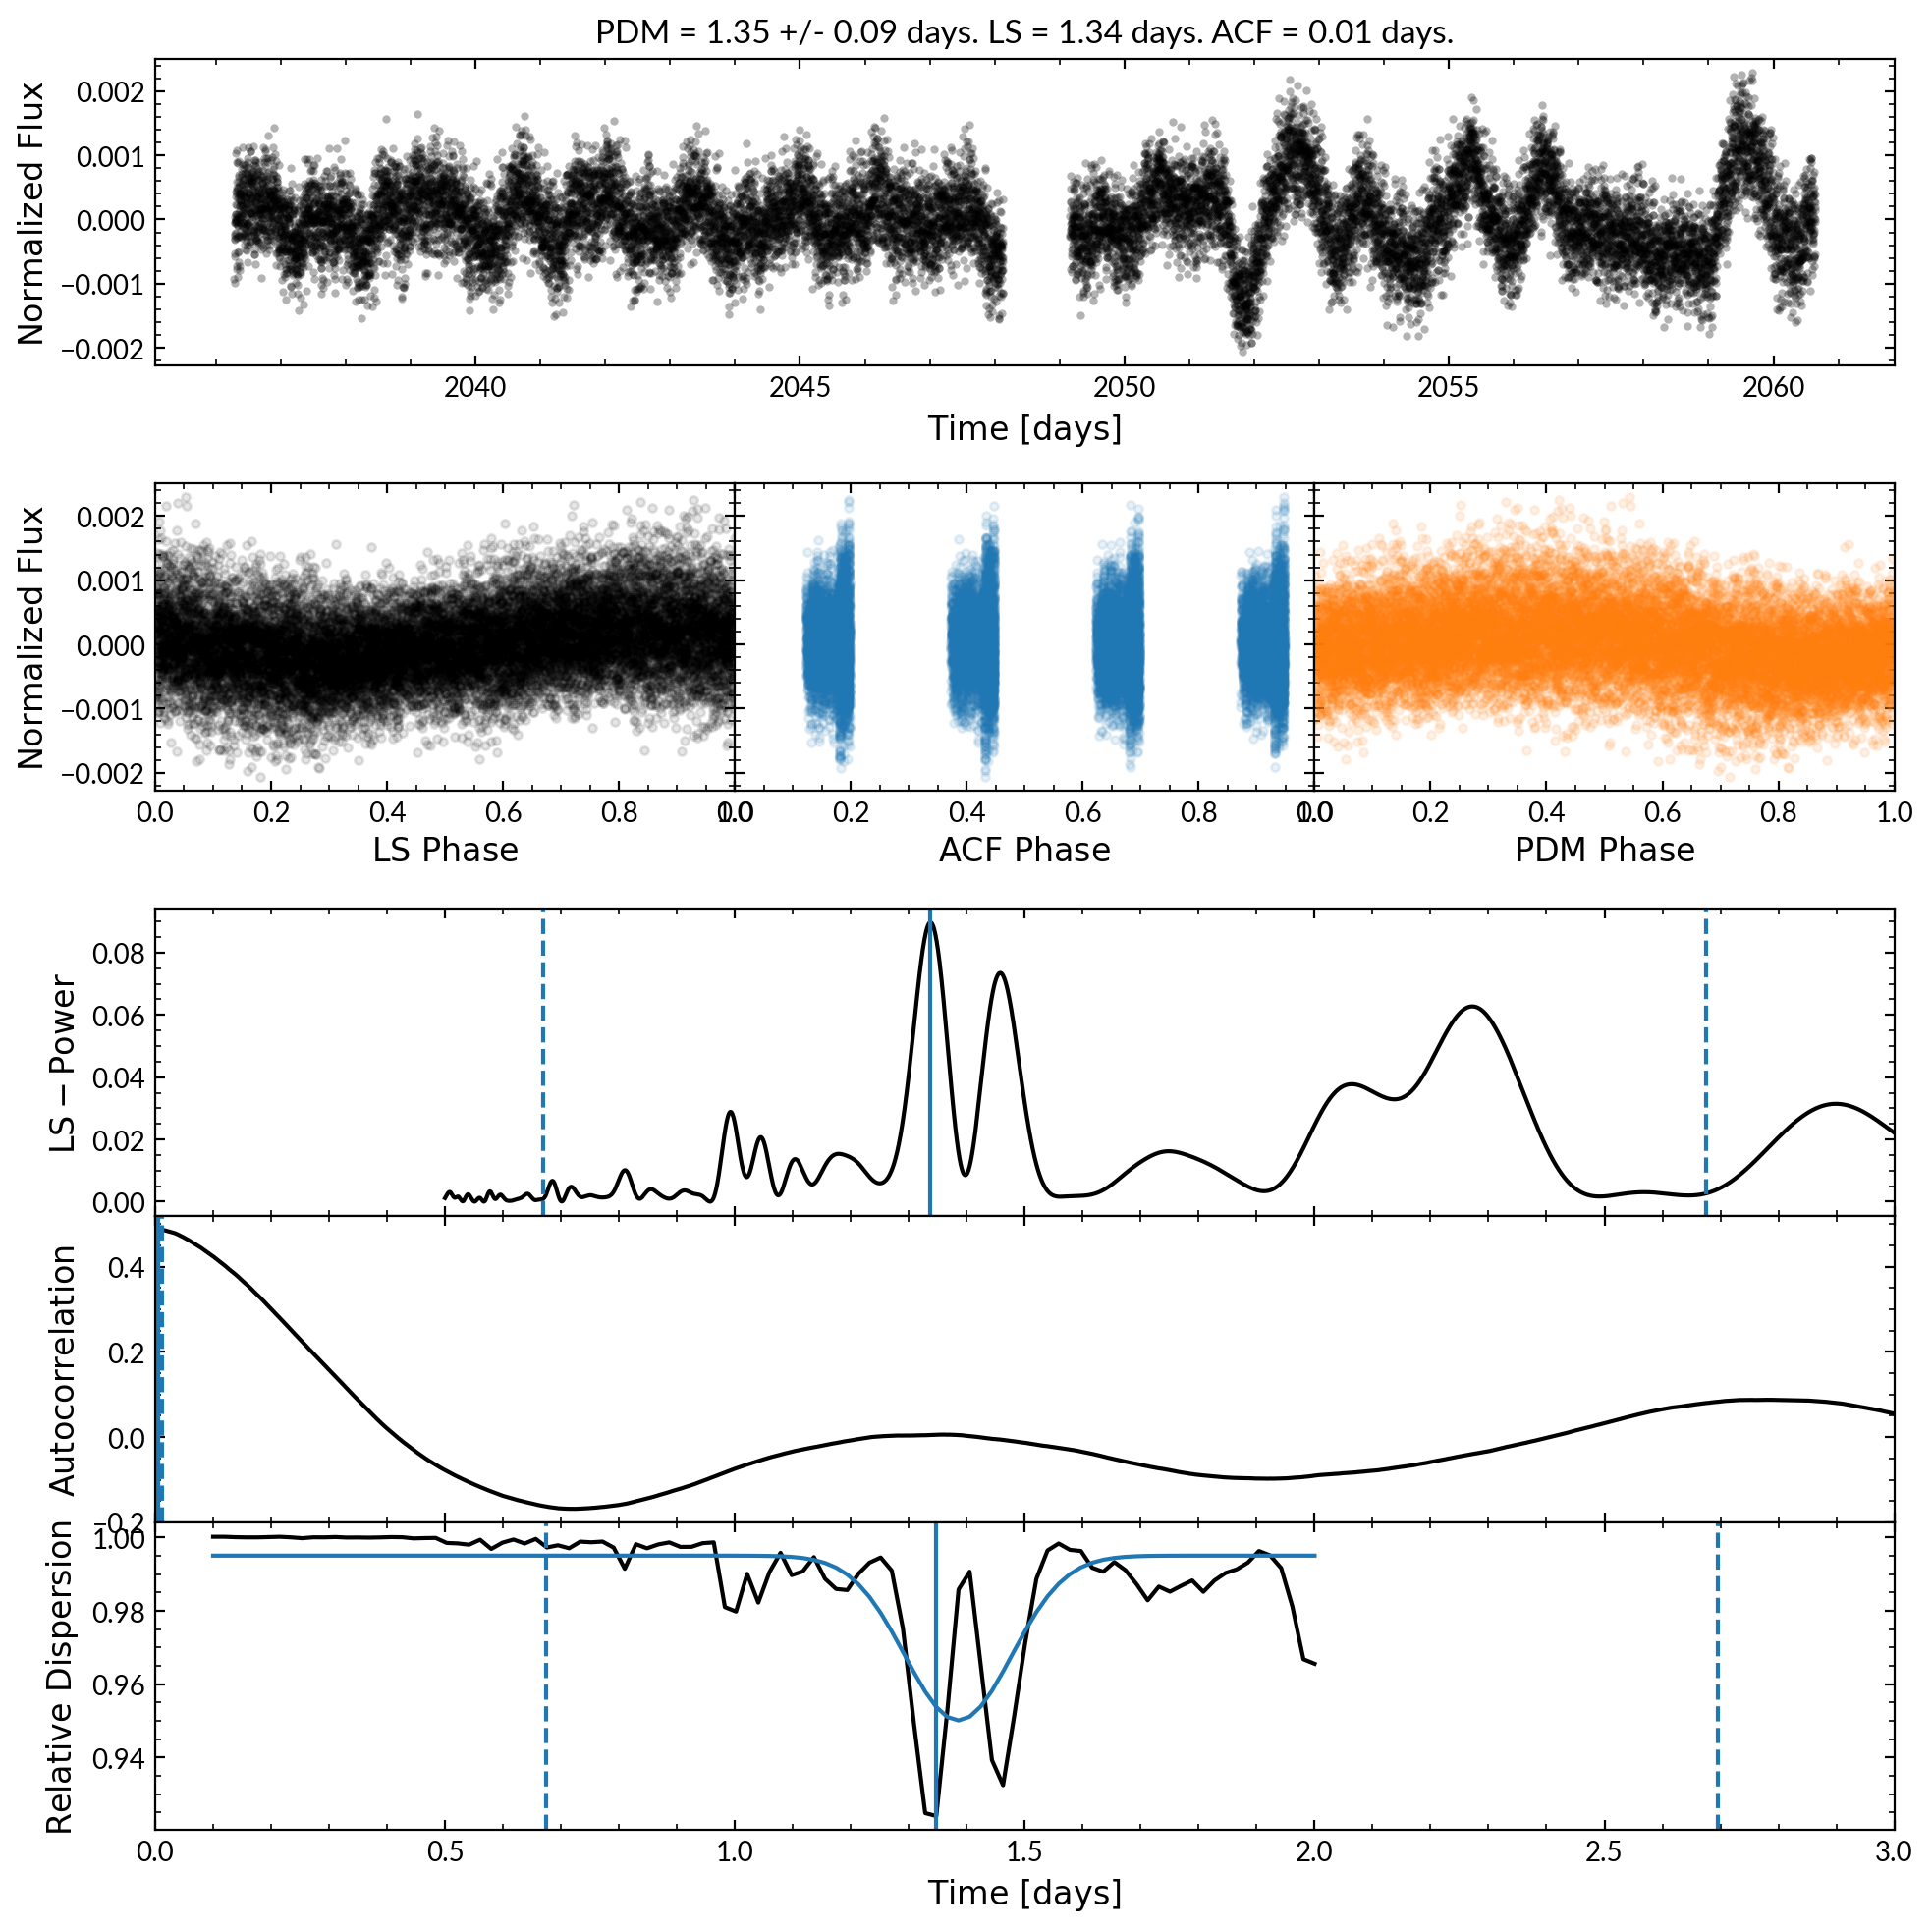

In [15]:
# Provide the list of methods and xlimits for the bottom panels
fig = rotate.big_plot(["ls", "acf", "pdm"], method_xlim=(0, 3));

In [39]:
rotate.acf_period, rotate.ls_period, rotate.pdm_period

(0.00972223, 10.026530464914813, 10.066666666666666)

# Rotation Period for our F-stars

In [ ]:
url = "https://raw.githubusercontent.com/SarahBarbosa/ring-like-structure/main/data/Fstars_names.txt"
stars = pd.read_csv(url, header=None, names=["Name"])
stars["RotP"] = float("nan")

for i, star in enumerate(stars["Name"]):
    try:
        lc = lk.search_lightcurve(star).download()
        pg = lc.to_periodogram(maximum_period=100)
        period = pg.period_at_max_power.value
        stars.at[i, "RotP"] = period
    except Exception as e:
        print(f"An error occurred for star {star}: {e}")

print("Process completed.")

An error occurred for star HD 189: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))


No data found for target "HD 615".
ERROR:lightkurve.search:No data found for target "HD 615".


An error occurred for star HD 615: 'NoneType' object has no attribute 'to_periodogram'


No data found for target "HD 1418".
ERROR:lightkurve.search:No data found for target "HD 1418".


An error occurred for star HD 1418: 'NoneType' object has no attribute 'to_periodogram'


...

An error occurred for star HD 212598: 'NoneType' object has no attribute 'to_periodogram'


No data found for target "HD 221644".
ERROR:lightkurve.search:No data found for target "HD 221644".


An error occurred for star HD 221644: 'NoneType' object has no attribute 'to_periodogram'


No data found for target "HD 223436".
ERROR:lightkurve.search:No data found for target "HD 223436".


An error occurred for star HD 223436: 'NoneType' object has no attribute 'to_periodogram'
Process completed.


In [ ]:
stars.to_csv("Fstars_with_periods.csv", index=False)